# **Segmentación de Ambientes Agroclimáticos Críticos para Cultivo de Maíz en la Provincia del Guayas (2015-2025)**

Este pipeline presenta una arquitectura modular que procesa 11 años de datos históricos satelitales (2015-2025). Su objetivo es transformar registros climáticos crudos en variables de decisión agronómica de alta precisión, permitiendo modelar el comportamiento del cultivo de maíz (*Zea mays*) frente a la variabilidad climática de la provincia del Guayas.

Datos: **NASA POWER**

 **Objetivos**
* **Segmentación:** Dividir los 11 años en grupos con lógica estadística.

* **Ambientes críticos para el maíz:** Identificar cuándo el clima se vuelve peligroso (Sequía o Inundación).

* **Temporalidad:** Analizar una década completa para ver tendencias.

In [114]:
# Importamos las librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [115]:
# Importamos los datos históricos del clima
data = pd.read_csv('HISTORIAL_CLIMATOLÓGICO_10_AÑOS_FECHAS.csv', sep=";")

In [116]:
# Inspeccionamos los primeros 5 registros del dataset
data.head()

,DATE,ALLSKY_SFC_SW_DWN,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,IMERG_PRECTOT,WSC,WS2M,GWETTOP,PS
0,1/1/2015,10.72,29.53,38.70,23.71,58.81,0.57,0.11,3.04,3.07,0.26,100.06
1,2/1/2015,14.43,29.29,38.44,23.58,59.69,0.55,0.00,3.37,3.43,0.27,100.04
2,3/1/2015,14.37,29.24,37.73,23.55,58.10,1.20,2.96,3.36,3.36,0.27,100.01
3,4/1/2015,10.64,28.79,36.98,23.29,60.36,4.35,0.88,3.46,3.38,0.43,100.15
4,5/1/2015,14.78,29.36,37.99,23.39,58.16,0.19,0.07,2.71,2.69,0.41,100.15


In [117]:
data.shape # Verificamos las dimensiones de entrada del dataset (filas, columnas)

(4018, 12)

In [118]:
# Verificamos el contenido y formato de las variables con .info()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4018 entries, 0 to 4017
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   DATE               4018 non-null   object 
 1   ALLSKY_SFC_SW_DWN  4018 non-null   float64
 2   T2M                4018 non-null   float64
 3   T2M_MAX            4018 non-null   float64
 4   T2M_MIN            4018 non-null   float64
 5   RH2M               4018 non-null   float64
 6   PRECTOTCORR        4018 non-null   float64
 7   IMERG_PRECTOT      4018 non-null   float64
 8   WSC                4018 non-null   float64
 9   WS2M               4018 non-null   float64
 10  GWETTOP            4018 non-null   float64
 11  PS                 4018 non-null   float64
dtypes: float64(11), object(1)
memory usage: 376.8+ KB


# **Pre-procesamiento y Estructuración (ETL)**

In [119]:
# Eliminamos las variables no necesarias en el análisis
data.drop(['T2M','IMERG_PRECTOT','WSC'],axis=1, inplace=True)

**Importante:** Debemos calcular manualmente la temperatura media; esto reduciría el sesgo en el cluster, ya que al usar la temperatura del satélite, haría que la ETo fuera tan baja que el balance hídrico parecía positivo incluso en meses secos.

No podemos lanzar el modelo sobre fechas desordenadas. Primero, prepararemos el **esqueleto** del dataset.

In [120]:
#Renombramos las columnas del DataFrame
data.rename(columns={
    'DATE':'fecha','T2M':'temp_media', 'T2M_MAX':'temp_max', 'T2M_MIN':'temp_min',
    'ALLSKY_SFC_SW_DWN':'radiacion',  'WS2M':'vel_viento','PRECTOTCORR':'lluvia','RH2M':'humedad', 'GWETTOP':'hum_suelo', 'PS':'presion'
}, inplace=True)

In [121]:
# Verificamos las columnas renombradas
data.columns

Index(['fecha', 'radiacion', 'temp_max', 'temp_min', 'humedad', 'lluvia',
       'vel_viento', 'hum_suelo', 'presion'],
      dtype='object')

In [122]:
# Establecemos la fecha cono índice de nuestro dataset
data.set_index('fecha', inplace=True)

# Convertir el índice actual es texto de Excel a objetos de tiempo reales  datetime64[ns]
data.index = pd.to_datetime(data.index, dayfirst=True) #Especificamos el horario global UTC en NASA POWER al descargar lo datos

# Ordenar cronológicamente (vital para que los promedios móviles no den basura)
data.sort_index(inplace=True)

# Verificar el cambio
print(data.index.dtype) # Ahora debe decir datetime64[ns]

datetime64[ns]


In [123]:
data.head() #Visualizamos los cambios en el dataset

,radiacion,temp_max,temp_min,humedad,lluvia,vel_viento,hum_suelo,presion
fecha,,,,,,,,
2015-01-01,10.72,38.70,23.71,58.81,0.57,3.07,0.26,100.06
2015-01-02,14.43,38.44,23.58,59.69,0.55,3.43,0.27,100.04
2015-01-03,14.37,37.73,23.55,58.10,1.20,3.36,0.27,100.01
2015-01-04,10.64,36.98,23.29,60.36,4.35,3.38,0.43,100.15
2015-01-05,14.78,37.99,23.39,58.16,0.19,2.69,0.41,100.15


# **Identificación de Outliers - IsolationForest**

Para confirmar que todo está bien, un gráfico rápido que compare la Temperatura Máxima y la Lluvia. Esto permitirá visualmente identificar si hay algún outlier (un valor exagerado por ejemplo 100°C o semejante).

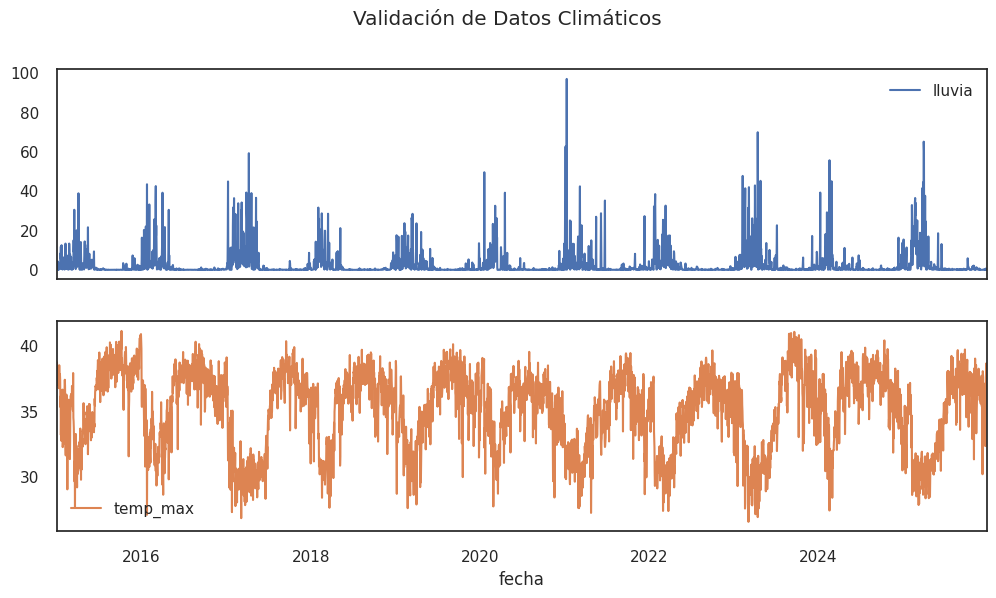

In [124]:
data[['lluvia','temp_max']].plot(subplots=True, figsize=(12, 6), title="Validación de Datos Climáticos")
plt.show()

Hacemos un análisis de correlación para ver cómo se comportan las variables de entrada entre sí. Útil para identificar redundancias (Requiere PCA), multicolinealidad y ruido.

In [125]:
correlacion = data.corr() # No es necesario excluir variables ya que un dataset climático no contiene variables categóricas.
correlacion

,radiacion,temp_max,temp_min,humedad,lluvia,vel_viento,hum_suelo,presion
radiacion,1.000000,0.047771,-0.017986,-0.033899,-0.030526,-0.031227,-0.019704,-0.039613
temp_max,0.047771,1.000000,-0.234328,-0.913196,-0.486118,0.643380,-0.824059,-0.215163
temp_min,-0.017986,-0.234328,1.000000,0.427491,0.264238,-0.333755,0.463753,-0.354281
humedad,-0.033899,-0.913196,0.427491,1.000000,0.508466,-0.756418,0.955123,0.010620
lluvia,-0.030526,-0.486118,0.264238,0.508466,1.000000,-0.355603,0.498916,0.044823
vel_viento,-0.031227,0.643380,-0.333755,-0.756418,-0.355603,1.000000,-0.804044,-0.053826
hum_suelo,-0.019704,-0.824059,0.463753,0.955123,0.498916,-0.804044,1.000000,-0.059031
presion,-0.039613,-0.215163,-0.354281,0.010620,0.044823,-0.053826,-0.059031,1.000000


<Axes: >

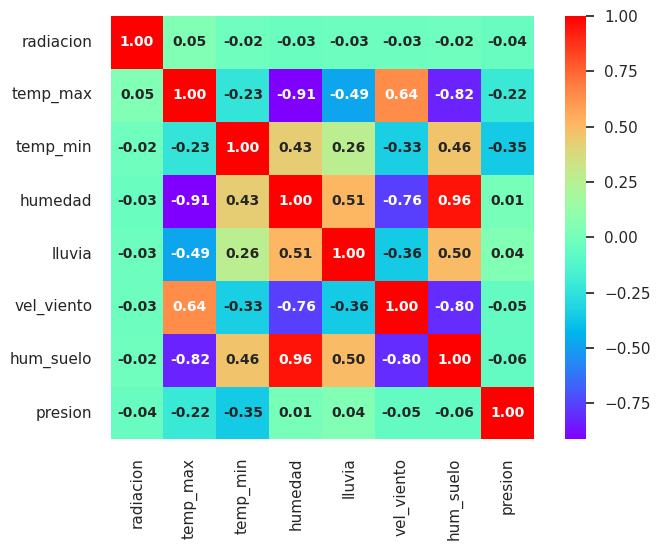

In [126]:
sns.set_theme(style='white')
paleta = sns.color_palette('rainbow', as_cmap=True)
sns.heatmap(correlacion,annot=True, fmt='.2f', square=True, annot_kws={'size':10,'fontweight':'bold'}, cmap=paleta)

**Importante:** Es recomendable eliminar variables que ocasionan multicolinealidad (que se comportan igual, como la humedad y la humedad del suelo > correlación alta), así como también variables "ruido" no útiles para este análisis. Con todo esto se evita que el modelo se distraiga con datos que no aportan nada al clúster o a la detección de errores climáticos.

In [127]:
# Definimos el grupo de variables
variables = data.drop(['humedad','vel_viento','presion'],axis=1).columns
X = data[variables]

In [128]:
# Importamos la libreria de IsolationForest de scikit-learn
from sklearn.ensemble import IsolationForest

In [129]:
# Instanciación del modelo - 'contamination' es el ratio esperado de anomalías en el dataset.
anomalias = IsolationForest(n_estimators=200,    # Suficiente para convergencia en la mayoría de los casos (tenemos > 4000 registros)
                            contamination=0.01,  # Ajusta según tu conocimiento agronómico de anomalías.
                            max_samples='auto',  # Típicamente 256 muestras por árbol (evita swamping).
                            max_features=0.1,    # ¡CRÍTICO! Solo usa el 10% de las variables (402) por árbol.
                            n_jobs=-1,           # Usa todos tus núcleos para procesar las 4k dimensiones.
                            random_state=42)

**Nota:** El algoritmo aísla estas combinaciones porque rompen la estructura de correlación que vimos en tu matriz (donde la radiación suele empujar la temperatura).
**Ejemplo:** Tener temperatura máxima con radiación casi nula es una contradicción (posiblemente un día muy nublado pero extremadamente cálido, lo cual es inusual).



In [130]:
# Ejecución del entrenamiento y predicción
# Fit calcula las particiones; predict asigna las etiquetas (-1 o 1)
data['anomalia'] = anomalias.fit_predict(X)
data['anomalia_score'] = anomalias.decision_function(X)

In [131]:
# Extracción de resultados para auditoría
anomalias_ident = data[data['anomalia']== -1]
anomalias_limp = data[data['anomalia'] == 1]

print(f"Total de registros procesados {len(X)}")
print(f"Anomalias detectadas {len(anomalias_ident)}")

Total de registros procesados 4018
Anomalias detectadas 41


Hay que determinar la naturaleza de esas 41 filas. Generalmente, en datos meteorológicos, estas anomalías se dividen en dos categorías:

* **Errores Instrumentales:** Fallos de sensor (ej. un valor de hum_suelo que no cambia en 24 horas o un pico de temp_max físicamente imposible).

* **Eventos Climáticos Extremos:** Días con heladas atípicas, olas de calor o precipitaciones intensas que se salen del patrón estocástico del resto del año.

In [132]:
#Ver el promedio de las variables en los datos normales vs las anomalías
comparativa = data.groupby('anomalia')[variables].mean()
print(comparativa)

          radiacion   temp_max   temp_min     lluvia  hum_suelo
anomalia                                                       
-1        13.249024  28.614390  23.736585  31.254878   0.941220
 1        13.806093  35.167174  22.408157   2.203236   0.469741


* **Lluvia:** Las anomalías promedian 31.25 mm, mientras que el resto promedia 2.20 mm. El algoritmo aisló los días de tormenta fuerte.

* **Temperatura Máxima:** En las anomalías, la temp_max cae a 28.6°C (frente a los 35.1°C normales). Esto es físicamente consistente: días de lluvia intensa tienen cielos cubiertos y menor radiación neta, lo que impide que la temperatura suba.

* **Humedad del Suelo:** Las anomalías están casi en saturación (0.94), mientras que el promedio normal es 0.46.

In [133]:
# Ver las 5 anomalías más extremas (las que tienen el score más bajo/negativo)
print("\nTop 5 Anomalías con score más bajo")
# La método .nsmallest trae directamente los 5 registros con el score más bajo
print(data.query("anomalia == -1").nsmallest(5, 'anomalia_score').round(3))


Top 5 Anomalías con score más bajo
            radiacion  temp_max  temp_min  humedad  lluvia  vel_viento  \
fecha                                                                    
2024-02-20      14.55     27.43     24.91    91.72   55.51        1.84   
2023-04-16      11.99     26.93     24.26    92.81   69.70        1.04   
2023-04-06       9.40     27.15     23.98    92.34   26.09        1.66   
2025-03-30      12.30     28.63     24.21    90.73   44.33        1.99   
2025-04-03      17.43     29.31     23.86    89.32   60.22        2.24   

            hum_suelo  presion  anomalia  anomalia_score  
fecha                                                     
2024-02-20       0.96   100.49        -1          -0.097  
2023-04-16       0.98   100.29        -1          -0.090  
2023-04-06       0.97   100.20        -1          -0.074  
2025-03-30       0.97   100.23        -1          -0.055  
2025-04-03       0.98   100.27        -1          -0.052  


* **Fechas:** Febrero, Marzo y Abril (temporada de invierno/lluvias en Guayas).

* **Magnitud:** El registro del 2023-04-16 tiene 69.70 mm de lluvia y una temp_max de solo 26.93°C.

* **Por qué son anomalías:** En el dataset de 4,018 días, tener casi 70 mm de lluvia es un evento de baja probabilidad estadística (un "outlier" de la distribución). El algoritmo los marca como anomalías porque se alejan del "día promedio" de Guayas, que es seco o de lluvia ligera con calor intenso (~35°C).

**Consideraciones de la identificación y análisis de anomalías**
Como estos datos no son errores de sensor sino lluvias reales y fuertes, hay dos vías dependiendo del objetivo de estudio.

* **Calculo de Rendimientos** (Yield): NO elimines estos datos. Estas lluvias son críticas para el balance hídrico del cultivo. Solo usa el Isolation Forest para detectar errores de sensor (ej. si tuvieras 70 mm de lluvia con 0.10 de humedad de suelo, eso sí sería un error).

* **Clustering de Clima Típico:** SÍ elimínalos o sepáralos. Estos 41 días ensuciarán tus clústeres porque representan eventos excepcionales que no definen el clima "normal" de la zona.

In [134]:
# Como haremos clustering agroclimático eliminaremos esos registros excepcionales
data = data.query("anomalia != -1").copy()
# Verificamos el total de registros posterior a la eliminación de anomalías
data.shape

(3977, 10)

#**Feature Engineering - Cálculo de Variables Agroclimáticas**

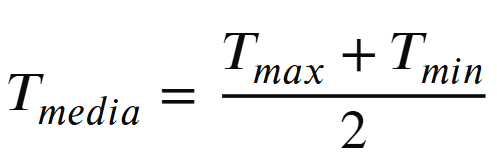

In [135]:
# Cálculos térmico de energía que el cultivo aprovecha
# TEMPERATURA MEDIA
data['temp_media'] = (data['temp_max'] + data['temp_min'])/2 # Cálculo manual para recuperar la amplitud térmica real del Guayas

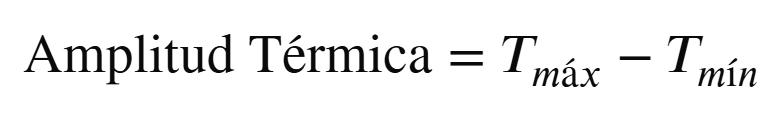

In [136]:
# AMPPLITUD TÉRMICA - DELTA T
data['delta_t'] = data['temp_max'] - data['temp_min'] # Delta Térmico (Importante para el llenado de grano)

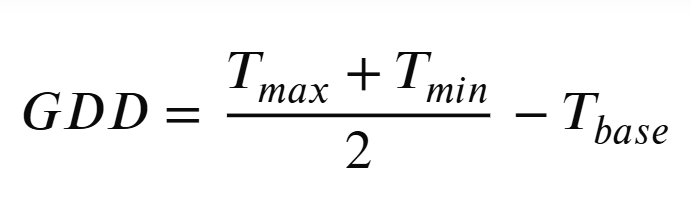

In [137]:
# GRADOS DÍAS ACUMULADOS
data['gdd'] = ((data['temp_max'] + data['temp_min']) / 2 - 10).clip(lower=0) #GDD (Grados Día Calor) - Umbral Maíz: 10°C

Al calcular la ETo y el balance hídrico, sepodrá identificar qué meses del registro histórico (2015-2025) fueron realmente críticos. Un balance negativo sostenido por más de 10 días es un indicador de estrés que el K-Means detectará de inmediato.

Método de cálculo de ETo para este análisis es **Hargreaves-Samani (1985)**


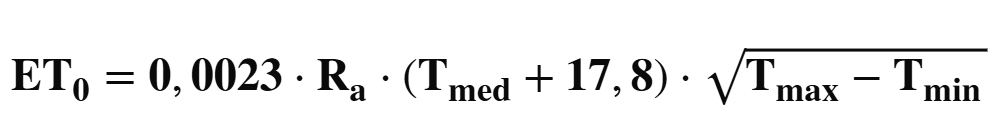


In [138]:
# EVAPOTRANSPIRACIÓN POTENCIAL (ETo) - Método Hargreaves-Samani
# Usamos la radiación (MJ/m²/día) convertida a mm con el factor 0.408
# La fórmula integra energía solar y la oscilación térmica como motor de evaporación.
data['eto'] = 0.0023 * (0.408 * data['radiacion']) * (data['temp_media'] + 17.8) * np.sqrt(data['delta_t'])

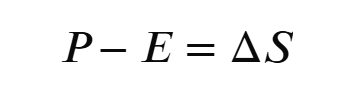

In [139]:
# BALANCE HÍDRICO Y ACUMULADOS
data['bal_hidrico'] = data['lluvia'] - data['eto']

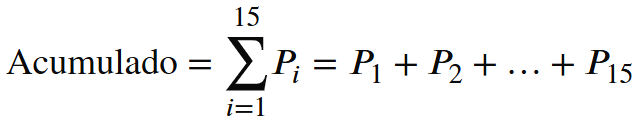

In [140]:
# PRECIPITACIÓN ACUMULADA 15 DÍAS
data['lluvia_acum_15d'] = data['lluvia'].rolling(window=15).sum() # Lluvia Acumulada (Memoria hídrica de 15 días), mide la reserva de agua.

In [141]:
# LIMPIEZA FINAL
data.dropna(inplace=True) # Eliminamos los NaN del 01-01-2015 al 14-01-2015

print("Variables agroclimáticas consolidadas.")
print(data[['gdd', 'eto', 'bal_hidrico']].tail().round(3))

Variables agroclimáticas consolidadas.
               gdd    eto  bal_hidrico
fecha                                 
2025-12-27  19.450  2.752       -2.052
2025-12-28  19.210  2.729       -2.349
2025-12-29  19.835  2.972       -2.952
2025-12-30  19.645  1.600       -1.500
2025-12-31  20.140  2.503       -2.443


Verificamos que los valores calculados tengan coherencia agronómica.

* **GDD:** Debería estar en un rango de 10 a 18 (para el clima del Guayas). Si se evidencia un 500 o  -5, el cálculo falló.

* **ETo:** Debería oscilar entre 3 mm y 7 mm diarios. En caso de presentar 0 o 100, la fórmula de Hargreaves tiene un error de unidades.

* **Balance Hídrico:** Verificamos que sea la resta lógica entre lluvia y evaporación.

#**Modelo K-Means**

**Preparación para el Clustering (K-Means)**

Antes de lanzar el algoritmo, hay que tener presente que K-Means es sensible a las escalas (por ejemplo, la lluvia puede ser de 0 a 100, mientras que el GDD es de 5 a 15).

¿Cómo procederemos?

* **Normalización:** Usaremos StandardScaler para que todas tengan el mismo peso estadístico.

* **Selección de Features:** Para el clustering, es sugerible usar: ['gdd', 'delta_t', 'eto, 'lluvia_acum_15d', 'hum_suelo','bal_hidrico']. Esta combinación separa perfectamente los **ambientes** de cultivo.

In [142]:
# Importamos librería para escalar las variables X
from sklearn.preprocessing import StandardScaler

# 1. Seleccionamos las variables agroclimáticas clave para el modelo
variables = ['gdd', 'delta_t', 'eto', 'lluvia_acum_15d','hum_suelo','bal_hidrico']
X = data[variables]

# 2. Estandarización (Media = 0, Desviación Estándar = 1)
ss = StandardScaler()
X_escalado = ss.fit_transform(X)

Para el clustering que haremos, estas variables separan el dataset en dimensiones físicas reales:

* **GDD y Delta T** definen la energía térmica.

* **Húmedad del suelo y Lluvia Acumulada 15 días** define la disponibilidad de agua.

* **Eto** define la demanda atmosférica.

Ahora hay que decidir cuántos grupos (clusters) existen en la zona del Guayas. **No podemos adivinar**. Usaremos el Método del Codo (Elbow Method) para ver dónde la inercia del modelo deja de caer drásticamente.

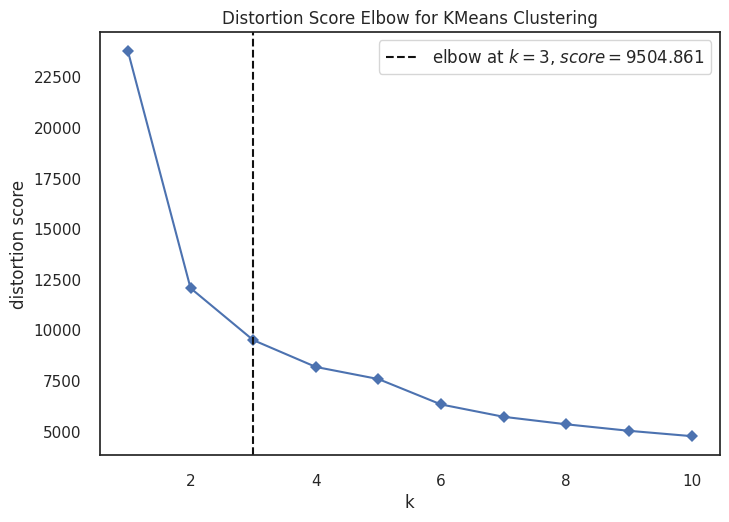

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [143]:
from yellowbrick.cluster import KElbowVisualizer

# Configuramos el modelo y el visualizador
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(1,11), timings=False)

visualizer.fit(X_escalado)      # Entrena y grafica
visualizer.show()               # Muestra el "codo" exacto

In [144]:
# 1. Entrenamos el modelo con k=3
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
data['cluster'] = kmeans.fit_predict(X_escalado)

# 2. Verificamos cuántos días cayeron en cada categoría
print("Distribución de días por cluster:")
print(data['cluster'].value_counts())

# 3. Análisis de Perfiles (La parte "Exquisita")
# Agrupamos por cluster para ver el promedio de cada variable y entender qué es cada grupo
perfil_clusters = data.groupby('cluster')[variables].mean().round(3)
print("\nPerfil promedio de cada Cluster:")
print(perfil_clusters)

Distribución de días por cluster:
cluster
2    2142
0    1225
1     596
Name: count, dtype: int64

Perfil promedio de cada Cluster:
            gdd  delta_t    eto  lluvia_acum_15d  hum_suelo  bal_hidrico
cluster                                                                 
0        18.139   11.079  1.877           38.090      0.621       -0.013
1        16.921    7.423  1.581          122.631      0.836        8.327
2        19.666   15.195  2.454            5.401      0.282       -2.192


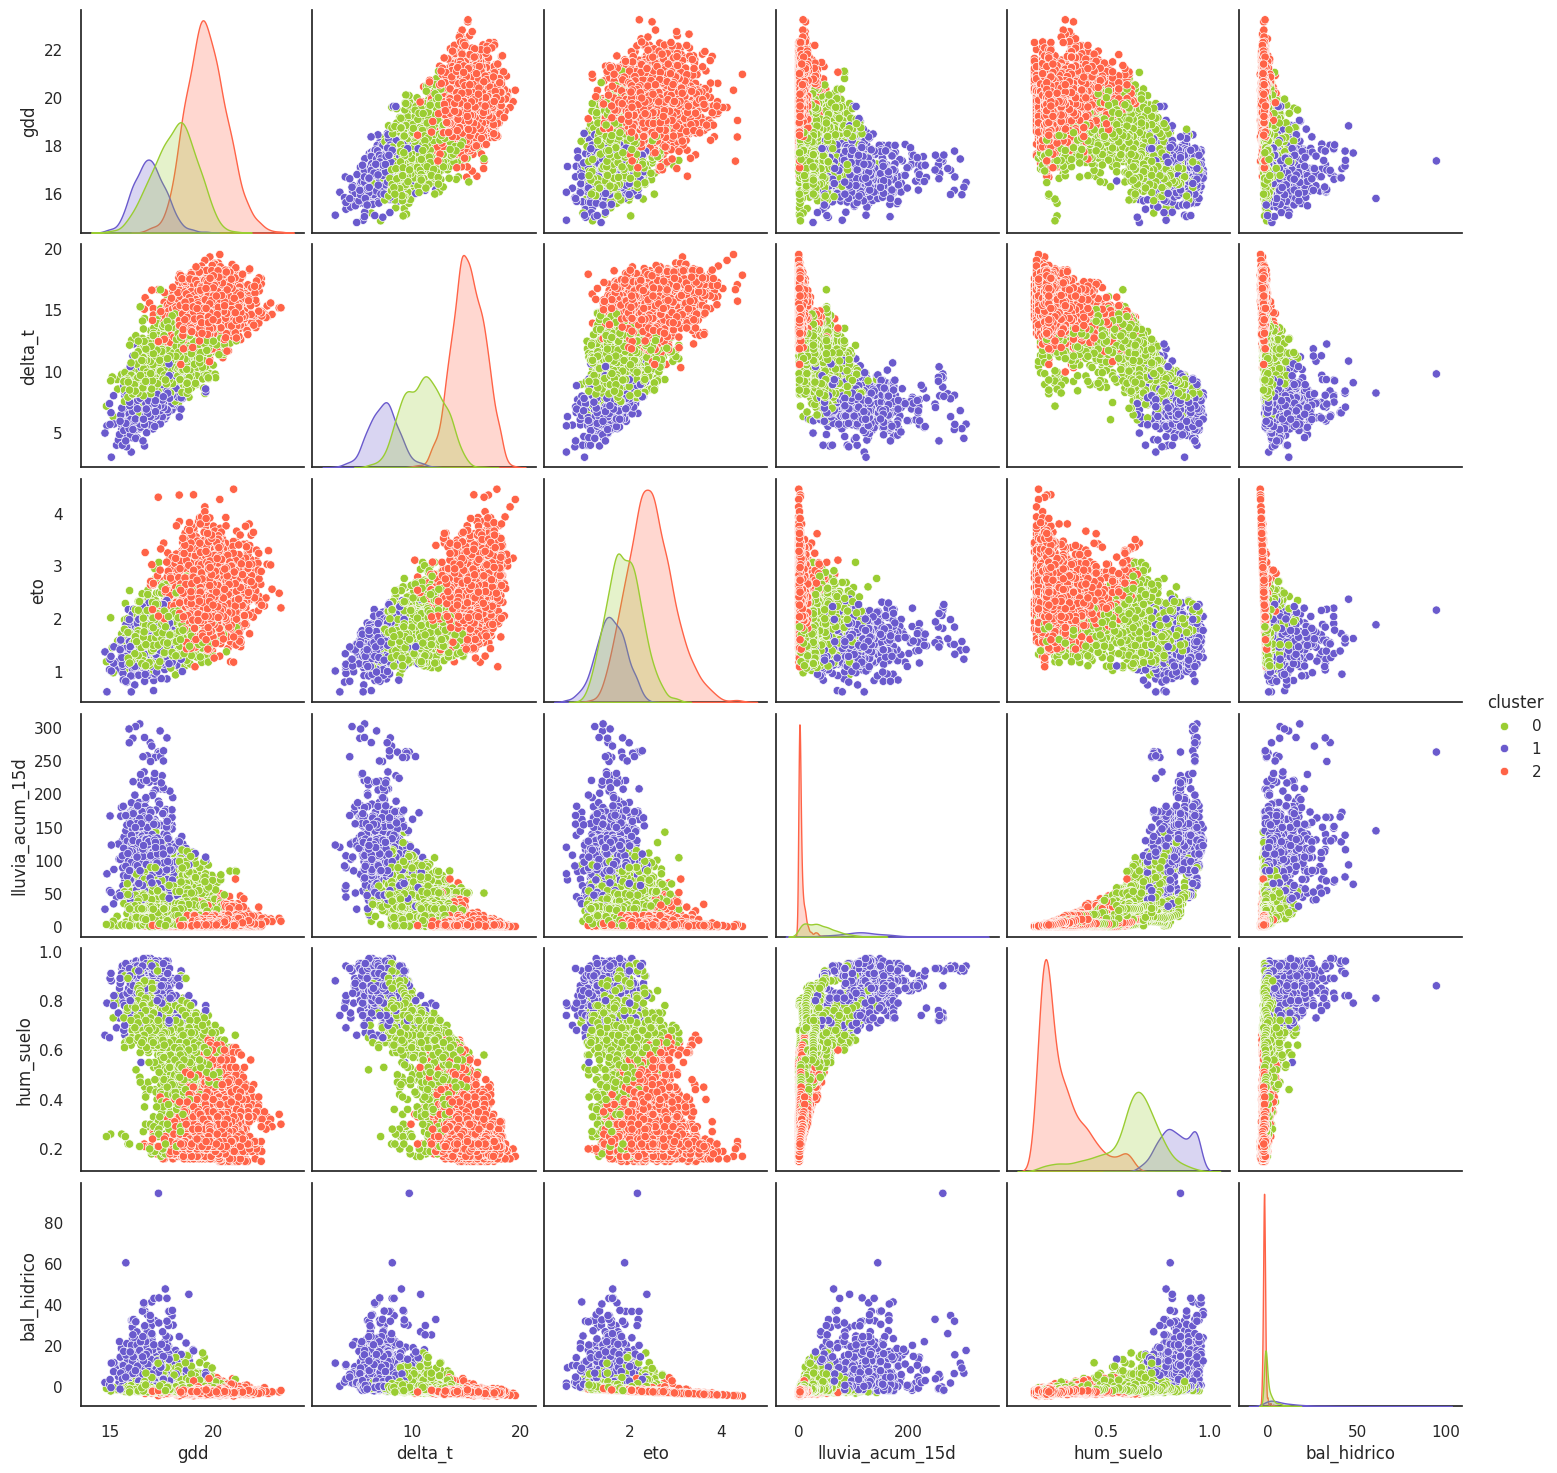

In [145]:
# Mapeamos los 'Estados' una sola vez en el DataFrame principal
clusteres = {0:'Ambiente Óptimo',1:'Exceso Hídrico', 2:'Déficit Hídrico'}
data['Estado'] = data['cluster'].map(clusteres)

# Con seaborn creamos una vista rápida de cómo se separan los clusters
paleta = {0:'yellowgreen',1:'slateblue',2:'tomato'}
sns.pairplot(data[variables + ['cluster']], hue='cluster', palette=paleta, diag_kind='kde')
plt.show()

**Interpretación de los Clusters**

* **Cluster 0 (Transición / Óptimo):** Con 1,225 días, presenta un equilibrio. Humedad de suelo moderada (0.62) y acumulados de lluvia manejables (38.1 mm). Es el ambiente donde el maíz suele encontrar su zona de confort en la zona. El balance hídrico es ligeramente negativo (-0.013).

* **Cluster 1 (Invierno / Saturación)**: El menos frecuente (596 días). Se define por la lluvia acumulada extrema (122.63 mm en 15 días) y una humedad de suelo cercana a la saturación (0.84). Aquí el Delta T cae a 7.42°C, típico de días nublados y lluviosos. El balance hídrico se dispara a 8.33

* **Cluster 2 (Verano / Déficit Hídrico)**: Es el más frecuente con 2,142 días. Tiene el GDD más alto (19.67) y el Delta T más fuerte (15.2°C), pero una humedad de suelo crítica (0.28). Es el escenario de máxima demanda evaporativa y nula reserva hídrica con balance hídrico negativo (-2.19), el cultivo agota sus reservas.


**Visualización del Espacio de Estados (Jointplot)**
Para validar que los clusters no se solapan de forma caótica, lo más profesional es graficar la Humedad del Suelo vs. GDD. Esto nos mostrará cómo la energía térmica se separa según la disponibilidad de agua.

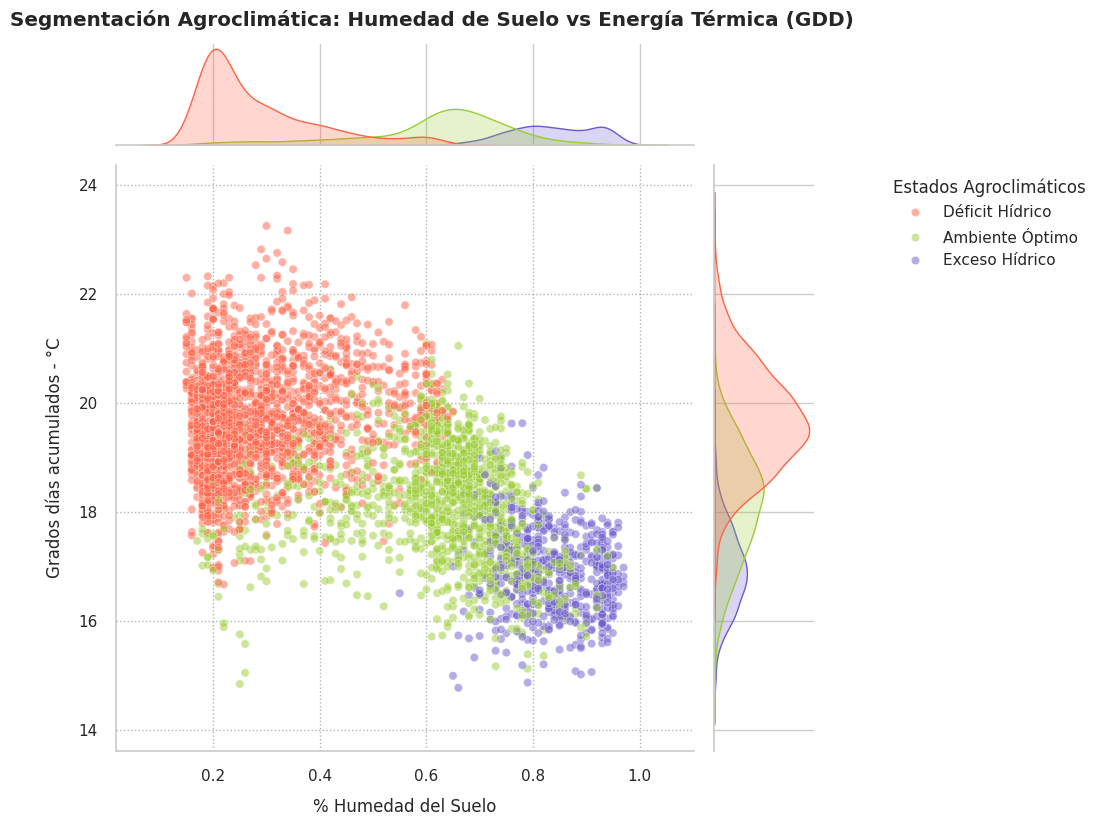

In [146]:
# Graficamos
sns.set_theme(style='whitegrid')
paleta = {'Exceso Hídrico':'slateblue','Déficit Hídrico':'tomato','Ambiente Óptimo':'yellowgreen'}
ax = sns.jointplot(data=data,x='hum_suelo', y='gdd', palette=paleta, hue='Estado', height=8, alpha=0.5)
ax.set_axis_labels('% Humedad del Suelo', 'Grados días acumulados - °C', fontsize=12, labelpad=10)

# Añadimos detalles al grafico
plt.suptitle('Segmentación Agroclimática: Humedad de Suelo vs Energía Térmica (GDD)',y=1.02, fontweight='bold')
plt.legend(title='Estados Agroclimáticos', bbox_to_anchor=(1.7,1))
plt.grid(zorder=0, ls=':', lw=1, color='grey', alpha=0.6)

Como ya cada día tiene un número, ahora queremos saber cuántos días seguidos se queda el clima en el grupo de "Sequía".

In [147]:
# 1. Identificamos el estado de estrés para el Maíz (Cluster 0)
data['es_estres'] = (data['cluster'] == 2).astype(int)

# 2. Detectamos cambios y creamos IDs de rachas consecutivas
data['cambio_estado'] = data['es_estres'].ne(data['es_estres'].shift()).cumsum()

# 3. Calculamos la duración de las rachas de estrés real
rachas_estres = data[data['es_estres'] == 1].groupby('cambio_estado').size()

print(f"Número total de rachas de estrés detectadas: {len(rachas_estres)}")
print(f"Duración máxima de una racha de estrés: {rachas_estres.max()} días")
print(f"Duración promedio de las rachas: {rachas_estres.mean():.2f} días")

# 4. Top 5 de las rachas más largas (¿Cuándo ocurrieron?)
top_5_rachas = rachas_estres.sort_values(ascending=False).head(5)
print("\nTop 5 Rachas más críticas (Duración en días):")
print(top_5_rachas)

Número total de rachas de estrés detectadas: 201
Duración máxima de una racha de estrés: 99 días
Duración promedio de las rachas: 10.66 días

Top 5 Rachas más críticas (Duración en días):
cambio_estado
25     99
43     99
99     97
45     92
359    84
dtype: int64


Ahora determinaremos las fechas exactas de esas rachas críticas. Esto te servirá para identificar qué años fueron los más duros para el cultivo en la zona del Guayas.

In [148]:
# 1. Identificar cuándo empiezan y terminan las rachas del Cluster 0
rachas_info = data[data['es_estres'] == 1].groupby('cambio_estado').agg(
    fecha_inicio=('lluvia', lambda x: x.index.min()), #Usamos los índice de las fechas
    fecha_fin=('lluvia', lambda x: x.index.max()),
    duracion_dias=('es_estres', 'count'))

# 2. Ver las 3 rachas más largas de la historia
top_3_rachas = rachas_info.sort_values(by='duracion_dias', ascending=False).head(3)

print("LAS 3 PEORES RACHAS DE SEQUÍA (2015-2025):")
print(top_3_rachas)

LAS 3 PEORES RACHAS DE SEQUÍA (2015-2025):
              fecha_inicio  fecha_fin  duracion_dias
cambio_estado                                       
25              2015-07-08 2015-10-14             99
43              2016-06-07 2016-09-13             99
99              2018-07-02 2018-10-06             97


**Nota**: Esos 99 días representan la duración sin interrupciones del estado de **Déficit Hídrico**. Del punto de vista agronómico es el tiempo que el maíz estuvo bajo las condiciones del Clúster 2 > estrés hídrico.

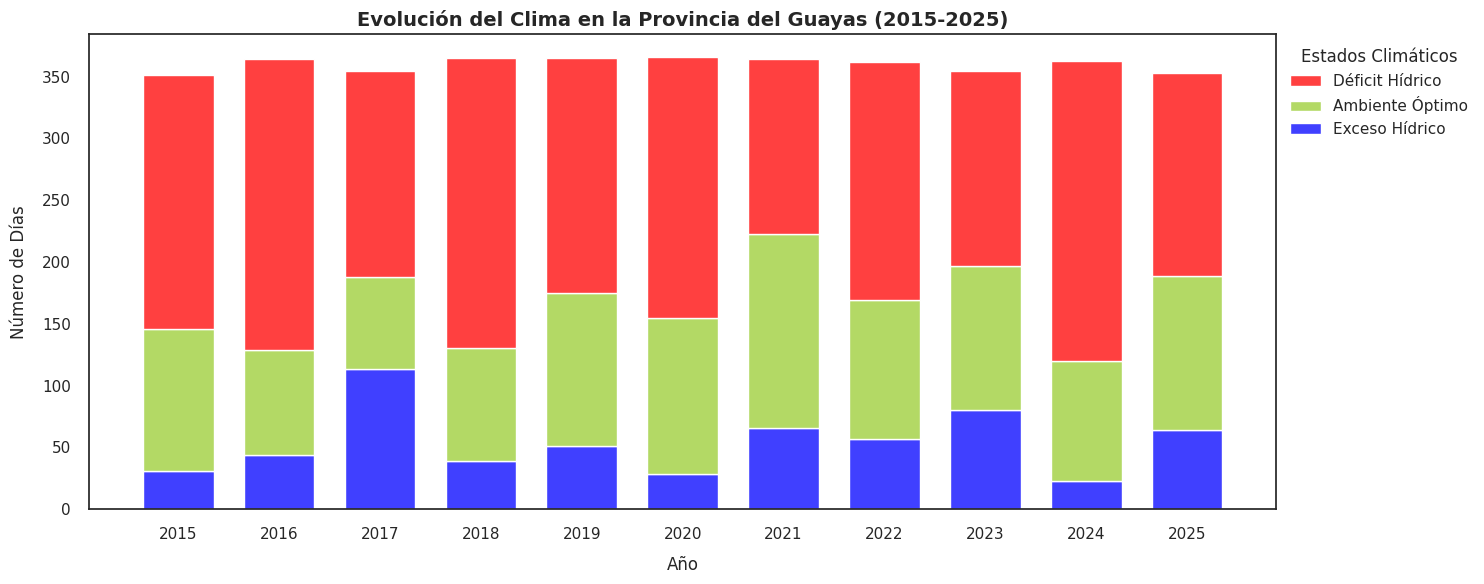

In [149]:
# 1. Configuración estética rápida
plt.figure(figsize=(15, 6))
sns.set_theme(style='white')
colores = ['red','yellowgreen','blue']

# 2. El gráfico: Seaborn se encarga de agrupar y contar por ti
sns.histplot(data=data, x=data.index.year, hue='Estado',
            multiple='stack', palette=colores, shrink=0.7, discrete=True)

# 3. Ajustes finales
plt.title('Evolución del Clima en la Provincia del Guayas (2015-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12, labelpad=10)
plt.ylabel('Número de Días', fontsize=12, labelpad=10)
plt.xticks(range(2015, 2026))

# Mover la leyenda fuera (Seaborn la crea automáticamente con los nombres de 'Estado')
sns.move_legend(plt.gca(),"upper left", bbox_to_anchor=(1, 1), title='Estados Climáticos')

plt.tight_layout()
plt.show()

**¿Qué dice este gráfico?**
* **Rojo (C0):** Es la "ventana de éxito". Entre más verde tenga un año, mejores fueron las condiciones para el maíz.

* **Azul (C1):** Representa los años con temporadas de lluvia más agresivas o eventos tipo "El Niño".

* **Verde (C2):** Si las barras rojas crecen cada año, la zona se está volviendo más árida en el caso de la provincia del Guayas es Tropico más seco.

Ahora calculamos procentualmente que clima manda en la zona del Guayas

In [150]:
# 1. Calcular el porcentaje de cada cluster
porcentajes = data['cluster'].value_counts(normalize=True) * 100

# 2. Mostrar los resultados de forma clara
print("¿Quién manda en el clima del Guayas?")
print(f"Estado Seco (C-1): {porcentajes[2]:.2f}% de los días")
print(f"Estado Óptimo (C-2): {porcentajes[0]:.2f}% de los días")
print(f"Estado Lluvioso (C-0): {porcentajes[1]:.2f}% de los días")

¿Quién manda en el clima del Guayas?
Estado Seco (C-1): 54.05% de los días
Estado Óptimo (C-2): 30.91% de los días
Estado Lluvioso (C-0): 15.04% de los días


**Interpretación Agrónomica:**

Esto demuestra que más del 50% del tiempo el clima es seco, cualquier herramienta que ayude a gestionar el riego o predecir estas rachas es oro puro para los agricultores.

In [151]:
# 1. Identificar automáticamente cuál es el número del cluster más seco
cluster_seco = data.groupby('cluster')['lluvia_acum_15d'].mean().idxmin()

# 2. Calcular las probabilidades
data['mes'] = data.index.month
probabilidad_mes = data.groupby('mes')['cluster'].value_counts(normalize=True).unstack() * 100

# 3. Imprimir la probabilidad del cluster identificado como seco
print(f"Probabilidad de Sequía (Cluster {cluster_seco}) por mes:")
print(probabilidad_mes[cluster_seco].fillna(0).round(1))

Probabilidad de Sequía (Cluster 2) por mes:
mes
1     27.0
2      3.9
3      2.5
4      9.6
5     24.0
6     45.8
7     78.6
8     97.7
9     99.4
10    92.4
11    89.1
12    68.3
Name: 2, dtype: float64


**Resumen del análisis agroclimático:**
* **De Junio a Noviembre:** Es la "Zona Roja". El Cluster 2 (Seco) domina casi el 90% del tiempo. Riesgo máximo.

* **De Enero a Abril:** Es la "Zona Azul". El Cluster 1 (Lluvias) y el Cluster 0 (Óptimo) se reparten los días. Es tu ventana de siembra.

* **Mayo y Diciembre:** Son meses de cambio. El clima "salta" de un estado a otro.

**Conclusión:** La aplicación de aprendizaje no supervisado sobre la serie histórica decenal identifica una estructura climática tripartita en la provincia del Guayas, donde el Estado de Déficit Hídrico (Cluster 2) es la condición prevalente, abarcando más del 50% del registro temporal. Los resultados demuestran que la variabilidad interanual no es uniforme, sino que se manifiesta a través de rachas secas prolongadas que contrastan con eventos de saturación extrema (Cluster 1), reduciendo significativamente los periodos de estabilidad termo-hídrica (Cluster 0). Esta caracterización permite establecer umbrales críticos de la variabilidad climática estacional en un factor de riesgo cuantificable para la rentabilidad del cultivo de maíz.